# Detector de Fake News con Regresión Logística

## 1. Introducción y objetivo:


* El objetivo será construir un modelo de Machine Learning (Aprendizaje Supervisado, clasificación) que sea capaz de detectar una noticia falsa.

## 2. Marco teórico Matemático:

* El proceso que sigue el modelo para la clasificación de las noticias está basado en las siguientes funciones matemáticas:
  * **A)** Función hipótesis (sigmoide): 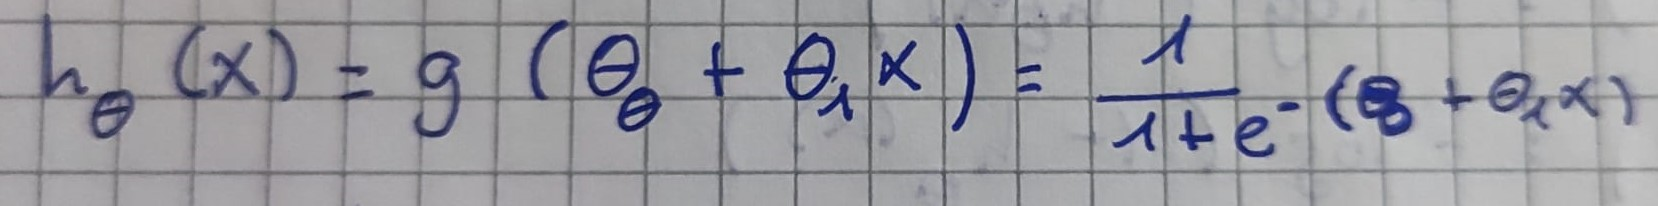
  * **B)** Función de Coste (y = 1 + y = 0): 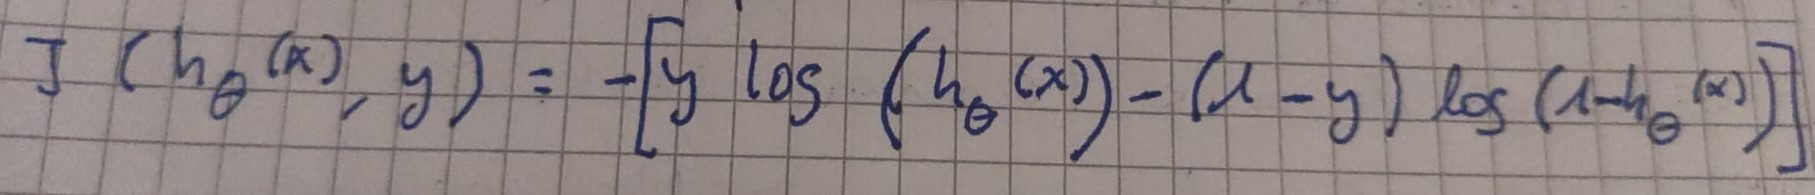
  * **C)** Función de Optimización: 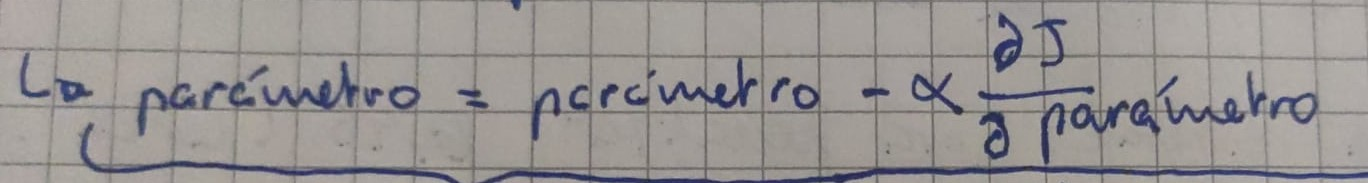

## 3. Conjunto de datos:

* Los datos han sido obtenidos en: [Kaggle](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset)
* Consta de dos archivos, el primero (True.csv) hace referencia a las noticias que no son fake news. El segundo (Fake.csv) son las noticias falsas.

## Lectura de los datos
---

In [6]:
import pandas as pd

# Creación de los dataframes
df_real = pd.read_csv('data/True.csv')
df_fake = pd.read_csv('data/Fake.csv')

## Modificación de los dataframes
---

In [ ]:
# Creación de las columnas que identificarán si una noticia es real o fake
df_real['label'] = "REAL"
df_fake['label'] = "FAKE"

# Crear dataframe final con la columna 'label'
df = pd.concat([df_real, df_fake], ignore_index=True)

In [ ]:
# Proceso para verificar el resultado
print(f"Noticias con la etiqueta 'REAL': {len(df_real)}")
print(f"Noticias con la etiqueta 'FAKE': {len(df_fake)}")
print(f"Noticias totales: {len(df)}") # => dataframe final tiene todas las noticias juntas

Noticias con la etiqueta 'REAL': 21417
Noticias con la etiqueta 'FAKE': 23481
Noticias totales: 44898


## Procesamiento de los datos
---

In [ ]:
from bs4 import BeautifulSoup, MarkupResemblesLocatorWarning
import warnings

# Evitar que BeautifulSoup llene de warnings el notebook
warnings.filterwarnings('ignore', category=MarkupResemblesLocatorWarning)

In [ ]:
# **** 1º ELIMINAR TAGS HTML ****
def html_cleaner(text):
      """
        Elimina los tags html de un texto usando BeautifulSoup,
        devolviendo texto plano.
        ARGS:
            - text (str): Objeto que contendrá el texto a limpiar
        EXPL:
            - 'html.parser': Procesa el HTML y crea un árbol de elementos.
            - get_text(): Extrae únicamente el texto eliminando las etiquetas html.
        RETURNS:
            - str: Texto sin etiquetas HTML
    """
      return BeautifulSoup(text, 'html.parser').get_text()

In [ ]:
import re

# **** 2º ELIMINACIÓN DE URLS ****
def urls_cleaner(text):
      r"""
        Elimina las urls del texto. Usando la expresión regular: 'https?://\S+'
        ARGS:
            - texto (str): Objeto que tendrá el texto
        EXPL:
            - r: Interpretará las \ no como caracteres de escape sino como texto crudo.
            -'https?://\S+': Patrón
            - '': Reemplazo
        RETURNS:
            - str: Sin el patrón 'https?://\S+'
    """
      return re.sub(r'https?://\S+', '', text)

In [ ]:
# **** 3º ELIMINACIÓN DE SIGNOS DE PUNTUACIÓN Y CONVERTIR A MINÚSCULAS ****
import string

def punct_cleaner(text):
    """
      Método que convierte a minúsculas y elimina signos de puntuación
    """
    text = text.lower()
    # Eliminar puntuación ASCII
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'[\u2018\u2019\u201C\u201D\u2013\u2014\u2026]', '', text)

    return text

### Tokenizar, eliminar stopwords y aplizar stemming

In [ ]:
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [ ]:
# Se debe descargar los símbolos de puntuación (1 vez)
nltk.download('punkt', quiet=True) # => quiet: evita mensajes de descarga
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [ ]:
# Procesamiento completo, incluido eliminar cabeceras: BOSTON, (reuters) - ...
def text_preprocessing(text):
  """Aplica todo el preprocesamiento"""
  # Eliminar cabeceras
  text = re.sub(r'^[A-Z\s,.]+ \([^)]+\)\s*[-]?\s*', '', text)
  text = html_cleaner(text)
  text = urls_cleaner(text)
  text = punct_cleaner(text)

  # Tokenizar
  tokens = word_tokenize(text)
  # Eliminar stopwords
  stop_words = set(stopwords.words('english')) # => guarda las stopwords en el idioma seleccionado
  tokens = [t for t in tokens if t not in stop_words]
  # Stemming
  stemmer = PorterStemmer()
  tokens = [stemmer.stem(t) for t in tokens]

  # Retornar string final
  return " ".join(tokens)

## Entrenamiento del modelo
---

In [ ]:
# Se utilizará 42k de las noticias. 40k para entrenamiento y 2k para test
df = df.sample(n=42000, random_state=42)

# Aplicar método de procesamiento de texto, debido a la cantida de noticias tardará unos minutos.
print("Procesando noticias....")
df['text_clean'] = df['text'].apply(text_preprocessing)
print("Completado")

Procesando noticias....
Completado


In [ ]:
# Datos de entrenamiento y de test
X_train, y_train = df['text_clean'][:40000], df['label'][:40000]
X_test, y_test = df['text_clean'][40000:], df['label'][40000:]

print("Noticias para entrenamiento: {}\nNoticias para test: {}".format(len(X_train), len(X_test)))

Noticias para entrenamiento: 40000
Noticias para test: 2000


Teniendo en cuenta que la IA (ninguna de ellas) entiende texto, se procede a vectorizar (convertir texto a números). Técnica usada: "Bag of Words".

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score

In [ ]:
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression(max_iter=1000) # => iterará máximo 1000 veces o hasta converger (punto óptimo)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Predicciones del modelo
X_test = vectorizer.transform(X_test)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
print("Precisión de mi modelo: {:.2f}".format(accuracy_score(y_test, y_pred)))

Precisión de mi modelo: 0.99


## Usar modelo ya entrenado con noticias nuevas
---

* El modelo ha sido entrenado con un conjunto de noticias en inglés, para utilizarlo con noticias en otros idiomas se deberá entrenar el modelo usando noticias en el idioma que se desee.

* Hay que tener en cuenta la época de las noticias. Hechos actuales que en el momento de las noticias que se han usado para entrenar el modelo pudieran ser inverosímiles las puede detectar como falsas o con porcentajes bajos.

In [ ]:
# Las noticias 1 y 3 son las reales
noticias_nuevas = [
    """WASHINGTON, July 13 (Reuters) - The sudden death of Senator Lindsey Graham and ongoing absence of Senator Mitch McConnell will weigh on Congress as it ​returns from its July 4 holiday break on Monday to grapple with key defense and national security legislation during a compressed four-week summer work period.""",
    """BREAKING NEWS!!! Science Magazine denies the existence of dinosaurs — urgent!!!""",
    """BOSTON, July 13 (Reuters) - An Iranian-born engineer was convicted on Monday of U.S. charges ​that he conspired to illegally export technology with potential application in military drones to a company ‌in Iran whose customers included the country's Islamic Revolutionary Guard Corps.""",
    """UNBELIEVABLE BUT TRUE!!!!! The Anunnaki left a genetic map in Antarctica!!!!"""
]

notic_prepro = [text_preprocessing(n) for n in noticias_nuevas]
notic_vector = vectorizer.transform(notic_prepro)

# Predicciones
prediccion = clf.predict(notic_vector)
probabilidad = clf.predict_proba(notic_vector)

for notic, pred, prob in zip(noticias_nuevas, prediccion, probabilidad):
  print(f"Noticia: {notic[:60]}")
  print(f"Predicción => {pred}")
  print(f"Probabilidad de ser REAL: {prob[1]:.2%} | Probabilidad de ser FALSA: {prob[0]:.2%}")
  print()

Noticia: WASHINGTON, July 13 (Reuters) - The sudden death of Senator 
Predicción => REAL
Probabilidad de ser REAL: 75.73% | Probabilidad de ser FALSA: 24.27%

Noticia: BREAKING NEWS!!! Science Magazine denies the existence of di
Predicción => FAKE
Probabilidad de ser REAL: 4.44% | Probabilidad de ser FALSA: 95.56%

Noticia: BOSTON, July 13 (Reuters) - An Iranian-born engineer was con
Predicción => REAL
Probabilidad de ser REAL: 99.85% | Probabilidad de ser FALSA: 0.15%

Noticia: UNBELIEVABLE BUT TRUE!!!!! The Anunnaki left a genetic map i
Predicción => FAKE
Probabilidad de ser REAL: 1.99% | Probabilidad de ser FALSA: 98.01%

